# Cone & Bowtie Plots

The redshift "cone" (or "pie wedge") is a particularly recognizable figure type in
cosmological-scale astronomy: the observer sits at the apex, an angle on the sky opens
the wedge, and redshift or distance runs outward along the radius. Plot a survey
this way and the **cosmic web** appears — galaxies strung along filaments, walls
bounding the empty voids between them.

These frames are the one thing in skyplothelper that is *not* a WCS sky frame.
They are purpose-built polar wedges with their own tick, label, and plotting
machinery — so the sky overlays from the other tutorials don't apply here, but a
small family of `cone_*` helpers does. This tutorial is a tour of that family, and
like the others it keeps two questions in view for every piece: **"how do I show
my data this way?"** and **"how do I adjust it?"**

We build a wedge, plot into it three ways (points, tracks, density), rotate it to
any orientation, fold it into the double-sided **bowtie**, add the second radial
axis that gives it extra utility (redshift *and* comoving distance at once, for
example), and finish on the observation that the frame is not really about
cosmology at all — any angle-versus-radius data belongs in a wedge.

## Contents

1. [Building the wedge](#1.-Building-the-wedge)
2. [Plotting in the wedge](#2.-Plotting-in-the-wedge)
3. [Orientation and rotation](#3.-Orientation-and-rotation)
4. [The bowtie](#4.-The-bowtie)
5. [The radial axis](#5.-The-radial-axis)
6. [Beyond cosmology](#6.-Beyond-cosmology)
7. [Putting it together](#7.-Putting-it-together)
8. [Where to go next](#8.-Where-to-go-next)

> **Note:** The distance/time conversions in §5 use `astropy.cosmology` and need
> SciPy (`pip install skyplothelper[cone]`); §2's smoothed density field borrows
> SciPy's `gaussian_filter` too. Everything else — the wedge geometry, plotting,
> orientation, and the bowtie — works without it.

In [1]:
import os

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from astropy.cosmology import Planck18
from matplotlib.colors import to_rgb
from scipy.ndimage import gaussian_filter

import skyplothelper as sph

# base='structural' tightens only the frame/tick *geometry* — it leaves colors and
# fonts to the docs light/dark theme, so it composes with the dark-figure pass
# (which sets a theme on top). We avoid base='standard', which would reset the theme.
sph.set_style(base="structural")


# Decoration adapts to the docs light/dark passes: read the active page color off the
# figure background and pick the matching annotation palette (accent/label/stars/...).
def annotation_palette():
    r, g, b = to_rgb(mpl.rcParams["figure.facecolor"])
    return sph.ANNOTATION_PALETTES["dark" if (0.299 * r + 0.587 * g + 0.114 * b) < 0.5
                                  else "publication"]


PAL = annotation_palette()
# `stars` is the palette's point color, designed to contrast with the page in both
# modes — exactly right for a dense scatter of galaxies. `accent` marks the few
# things we want to call out on top.
GALAXY = PAL["stars"]
ACCENT = PAL["accent"]

Throughout we use two **real** redshift-survey slices, cached as small CSVs under
`examples/data/` (see that folder's `README` for provenance and how they were
subsampled). Substitute your own table of `(ra, z)` and every call below applies
unchanged.

- **SDSS** — 8000 galaxies in a thin equatorial band that runs through the *Sloan
  Great Wall*; our single-wedge workhorse.
- **2dFGRS** — 5000 galaxies from each of the survey's two caps (North and South
  Galactic Pole), which drive the bowtie.

In [2]:
DATA = os.path.join("..", "..", "examples", "data")   # relative to docs/tutorials/

sdss = np.genfromtxt(os.path.join(DATA, "sdss_slice.csv"),
                     delimiter=",", names=True, encoding="utf-8")
tdf = np.genfromtxt(os.path.join(DATA, "2dfgrs_slice.csv"),
                    delimiter=",", names=True, dtype=None, encoding="utf-8")
tdf_cap = np.array([c for c in tdf["cap"]])            # 'NGP' / 'SGP' string column
NGP, SGP = tdf_cap == "NGP", tdf_cap == "SGP"

print(f"SDSS : {sdss['ra'].size} galaxies, "
      f"RA {sdss['ra'].min():.0f}–{sdss['ra'].max():.0f}°, "
      f"z {sdss['z'].min():.3f}–{sdss['z'].max():.2f}")
print(f"2dF  : {NGP.sum()} NGP + {SGP.sum()} SGP galaxies")

SDSS : 8000 galaxies, RA 120–250°, z 0.005–0.20
2dF  : 5000 NGP + 5000 SGP galaxies


## 1. Building the wedge

The figure below is a real slice of the universe: 8000 SDSS galaxies, the observer
at the apex, redshift growing outward — and the cosmic web laid bare, filaments and
walls threading between the voids. Everything in this tutorial builds up to (and
decorates) exactly this kind of picture, so it is worth naming the parts before we go on.

It all starts with `make_cone_frame`, whose geometry is set by four numbers: the
angular center and half-width open the wedge, and the radial minimum and maximum
set how deep it runs:

- `angle_center` / `angle_half_width` — the wedge spans
  `[center - half_width, center + half_width]` in your angular unit (R.A. degrees
  by default). It wraps correctly through 0°/360°.
- `r_min` / `r_max` — the radial range. `r_variable='redshift'` (the default)
  labels the radius as redshift; §5 swaps in real distances.

The call returns an ordinary matplotlib polar `Axes` with the wedge geometry,
ticks, grid, and labels already configured — you then draw into it with the
`cone_*` helpers. Here is the SDSS slice, and where each geometry knob lands:

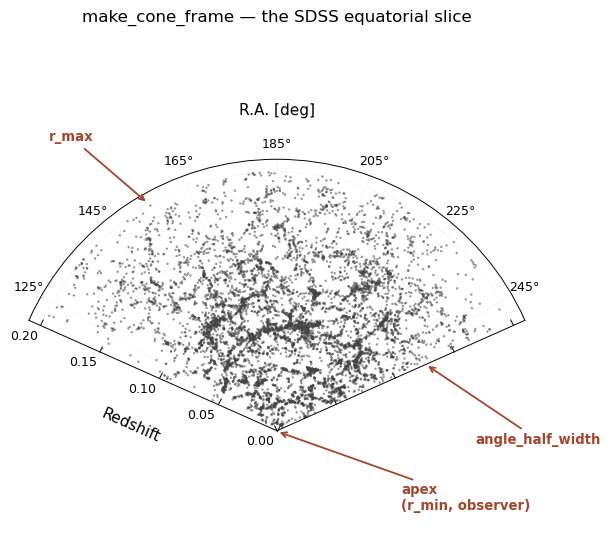

In [3]:
# fig-slug: anatomy
fig = plt.figure(figsize=(10.5, 6.2))
ax = sph.make_cone_frame(
    111, angle_center=185, angle_half_width=66,     # opens the wedge, RA ~120–250°
    r_min=0.0, r_max=0.20,                           # redshift 0 → 0.20
    angle_tick_spacing=20, r_tick_spacing=0.05,
    angle_label="R.A. [deg]", fig=fig,
)
sph.cone_scatter(ax, sdss["ra"], sdss["z"], s=3, c=GALAXY, alpha=0.55,
                 edgecolor="none")

# Annotate the geometry (axes-fraction placement; these are just teaching callouts).
note = dict(fontsize=9.5, color=ACCENT, fontweight="bold",
            xycoords="axes fraction", textcoords="axes fraction",
            arrowprops=dict(arrowstyle="->", color=ACCENT, lw=1.3))
ax.annotate("apex\n(r_min, observer)", xy=(0.50, 0.225), xytext=(0.75, 0.09),
            va="center", ha="left", **note)
ax.annotate("angle_half_width", xy=(0.80, 0.36), xytext=(0.90, 0.20),
            ha="left", **note)
ax.annotate("r_max", xy=(0.24, 0.685), xytext=(0.04, 0.81), ha="left", **note)
ax.set_title("make_cone_frame — the SDSS equatorial slice", pad=18)
fig.subplots_adjust(left=0.10, right=0.84, top=0.86, bottom=0.06)

The **Great Wall** is already visible — the dense arc of galaxies sweeping across
the middle of the wedge near redshift 0.08 — with darker voids above and below it.
That structure is the whole reason to plot a survey this way rather than as a flat
RA–z scatter: the wedge preserves the *fan* of sightlines from the observer, so a
wall really looks like a wall.

> **Tip:** `angle_center` and `angle_half_width` are in your angular unit, and the
> data you pass to `cone_scatter` is *always* in that same unit — degrees of R.A.
> here. If your catalog thinks in hours instead, pass `angle_unit='hour'` and give
> the center, half-width, and data all in decimal hours. Either way the frame
> handles the conversion to internal polar angle for you, including the wrap
> through 0°/360°.

## 2. Plotting in the wedge

The wedge is polar under the hood, so you can't use bare `ax.scatter` (it would
read your data as raw radians). Instead the `cone_*` helpers take your angle and
radius in *data* units and place them correctly. There are three ways to render a
catalog, in increasing density:

- **`cone_scatter`** — the workhorse: one marker per source. `cone_scatter_z`
  is the same but takes a *redshift* and converts it to the axis' radial
  coordinate for you (handy when the radius is a distance — §5).
- **`cone_plot`** — a connected line, for tracks and boundaries rather than a
  point cloud.
- **`cone_hexbin`** / **`cone_pcolormesh`** — density, for when the catalog is too
  crowded to see individual points.

First, points colored by a third quantity. `cone_scatter` forwards everything to
matplotlib's `scatter`, so `c=`/`cmap=`/`s=` all work. A useful thing to encode is
each galaxy's **local density** — the number of neighbors in its patch of the
wedge — which makes the walls glow and the voids go dark (color by anything that
*isn't* the radius; coloring by redshift here would just paint concentric rings).
For the colormap we use `sph.deepsky`, one of the package's bundled maps —
registered with matplotlib, so any `cmap=` accepts them by name (the full family
is in [Themes, Palettes & Fonts](styling.ipynb)):

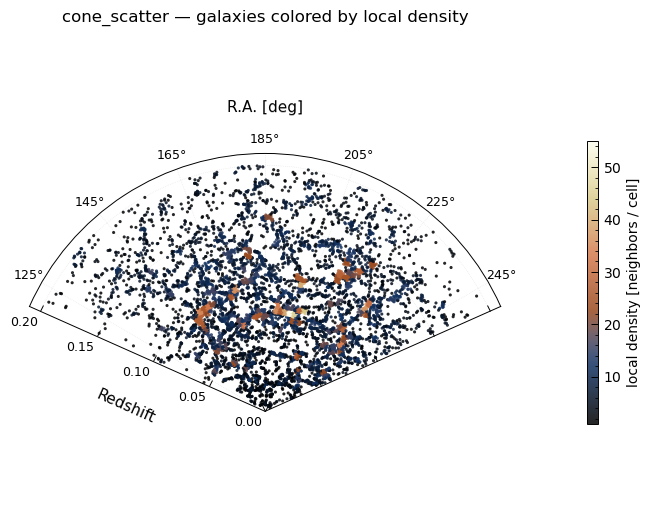

In [4]:
# fig-slug: scatter
# local projected density: how many galaxies share each cell of a coarse (RA, z) grid
ra_edges = np.linspace(120, 250, 53)
z_edges = np.linspace(0.0, 0.20, 41)
counts, _, _ = np.histogram2d(sdss["ra"], sdss["z"], bins=[ra_edges, z_edges])
ix = np.clip(np.digitize(sdss["ra"], ra_edges) - 1, 0, counts.shape[0] - 1)
iz = np.clip(np.digitize(sdss["z"], z_edges) - 1, 0, counts.shape[1] - 1)
local_density = counts[ix, iz]

fig = plt.figure(figsize=(10.5, 6.2))
ax = sph.make_cone_frame(111, angle_center=185, angle_half_width=66,
                         r_min=0.0, r_max=0.20, angle_tick_spacing=20,
                         r_tick_spacing=0.05, angle_label="R.A. [deg]", fig=fig)
sc = sph.cone_scatter(ax, sdss["ra"], sdss["z"], s=5, c=local_density,
                      cmap="sph.deepsky", alpha=0.85, edgecolor="none")
cb = sph.add_colorbar(sc, ax=ax, label="local density [neighbors / cell]",
                      shrink=0.6, pad=0.10, mode="simple")
ax.set_title("cone_scatter — galaxies colored by local density", pad=18)
fig.subplots_adjust(left=0.06, right=0.88, top=0.86, bottom=0.10)

> **Tip:** that colorbar comes from `sph.add_colorbar`, not matplotlib's
> `fig.colorbar` — prefer it here. It is theme-aware: it keeps the tick marks
> visible under the package styles (a plain colorbar's inward ticks disappear
> under the `structural`/`journal` bases, tucked beneath the color solid), and it
> adds `label=`, placement `mode=`, and stroke options in one call. On a cone
> (polar) frame pass `mode="simple"`: the default `"divider"` mode reserves a
> side panel with `make_axes_locatable`, which the wedge's fixed polar geometry
> can't host — `"simple"` attaches the bar cleanly instead.

For a crowded slice, switch from points to density. The two density helpers answer
different questions and — a common trip-up — take different *inputs*:

- **`cone_hexbin`** bins the raw catalog for you. Feed it the same
  `(angle, r)` arrays you gave `cone_scatter`; it counts points into hexagons in
  *screen* space, so the bins stay visually uniform across the fanning wedge.
- **`cone_pcolormesh`** draws a field you have *already* computed. You pass the
  cell **edges** and a 2-D array of values — ideal for a model, a selection
  function, a smoothed density map, or anything else defined on an `(angle, r)`
  grid.

Feeding a raw catalog to `cone_pcolormesh` is the usual mistake; it wants a grid,
not a point list. Side by side on the SDSS slice — the right panel bins the
catalog onto a grid and smooths it into a continuous density field, exactly the
kind of "already computed" input pcolormesh is for:

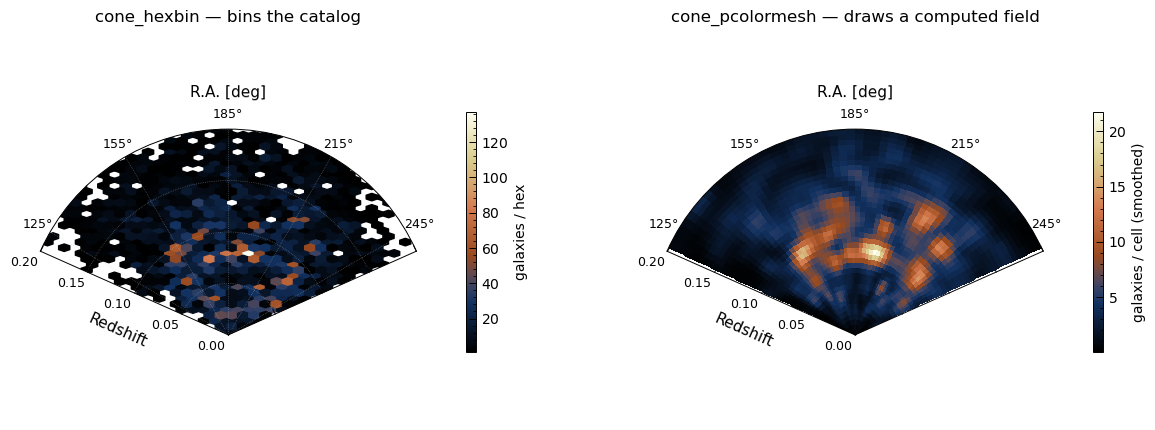

In [5]:
# fig-slug: density
fig = plt.figure(figsize=(12, 5.6))

# (a) hexbin — hand it the catalog directly
ax_h = sph.make_cone_frame(121, angle_center=185, angle_half_width=66,
                           r_min=0.0, r_max=0.20, angle_tick_spacing=30,
                           r_tick_spacing=0.05, angle_label="R.A. [deg]", fig=fig)
hb = sph.cone_hexbin(ax_h, sdss["ra"], sdss["z"], gridsize=32, cmap="sph.deepsky",
                     mincnt=1)
sph.add_colorbar(hb, ax=ax_h, label="galaxies / hex", shrink=0.55, pad=0.10,
                 mode="simple")
ax_h.set_title("cone_hexbin — bins the catalog", pad=16)

# (b) pcolormesh — compute a field first, then hand over edges + grid: here we
# bin the catalog onto (angle, z) cells and gaussian-smooth the counts into a
# continuous density field
ang_edges = np.linspace(120, 250, 53)          # 2.5°-wide angular cells
r_edges = np.linspace(0.0, 0.20, 41)           # 0.005-wide redshift cells
counts, _, _ = np.histogram2d(sdss["ra"], sdss["z"], bins=[ang_edges, r_edges])
density_field = gaussian_filter(counts, sigma=1.2)
ax_p = sph.make_cone_frame(122, angle_center=185, angle_half_width=66,
                           r_min=0.0, r_max=0.20, angle_tick_spacing=30,
                           r_tick_spacing=0.05, angle_label="R.A. [deg]", fig=fig)
qm = sph.cone_pcolormesh(ax_p, ang_edges, r_edges, density_field.T,
                         cmap="sph.deepsky")
sph.add_colorbar(qm, ax=ax_p, label="galaxies / cell (smoothed)", shrink=0.55,
                 pad=0.10, mode="simple")
ax_p.set_title("cone_pcolormesh — draws a computed field", pad=16)
fig.subplots_adjust(left=0.03, right=0.97, top=0.86, bottom=0.08, wspace=0.25)

Both surface the Great Wall as the bright band near z ≈ 0.08 — speckled hexagons
of raw counts on the left, a continuous smoothed field on the right. Hexbin is the
right default for a raw galaxy sample (uniform screen-space bins, no gridding
decisions); reach for pcolormesh when the thing you want to show is *already* a
grid — a smoothed density field, a completeness map, a mock catalog on cells.

`cone_plot` completes the trio: a connected line rather than a cloud. It's how you
overlay a boundary, a model track, or a selection edge on the wedge. Here it traces
a constant-luminosity-distance arc across the slice:

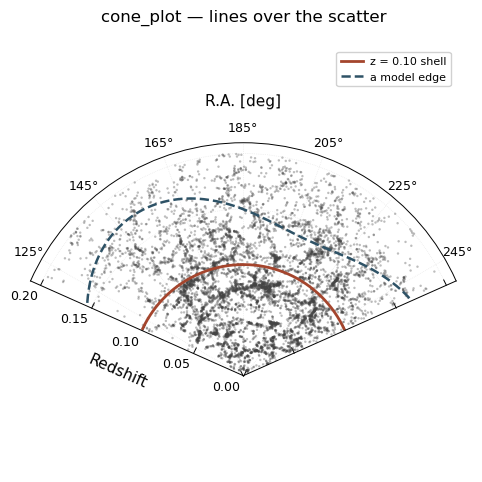

In [6]:
# fig-slug: lines
fig = plt.figure(figsize=(9, 5.6))
ax = sph.make_cone_frame(111, angle_center=185, angle_half_width=66,
                         r_min=0.0, r_max=0.20, angle_tick_spacing=20,
                         r_tick_spacing=0.05, angle_label="R.A. [deg]", fig=fig)
sph.cone_scatter(ax, sdss["ra"], sdss["z"], s=3, c=GALAXY, alpha=0.35,
                 edgecolor="none")
# a smooth arc at fixed redshift, plus a wavy "survey edge" track
arc_ra = np.linspace(120, 250, 200)
sph.cone_plot(ax, arc_ra, np.full_like(arc_ra, 0.10),
              color=ACCENT, lw=2.0, label="z = 0.10 shell")
edge_ra = np.linspace(120, 250, 200)
edge_z = 0.155 + 0.02 * np.sin(np.radians(edge_ra - 120) * 3)
sph.cone_plot(ax, edge_ra, edge_z, color=PAL["accent2"], lw=1.8, ls="--",
              label="a model edge")
ax.legend(loc="upper right", fontsize=8, framealpha=0.9)
ax.set_title("cone_plot — lines over the scatter", pad=18)
fig.subplots_adjust(left=0.06, right=0.94, top=0.86, bottom=0.10)

## 3. Orientation and rotation

A wedge does not have to open straight upward on the page. Two knobs place it anywhere:

- **`zero_location`** — which way the wedge's symmetry axis points: `'N'` (up,
  default), `'S'`, `'E'`, `'W'`.
- **`zero_offset`** — an extra rotation in degrees on top of that, for any angle in
  between.

A third knob, **`angle_direction`**, flips which way the angle *increases* around
the wedge: `-1` (the astronomical default, R.A. increasing counterclockwise) or
`+1` (the mathematical sense). The same SDSS slice, oriented five ways — watch the
apex and the R.A. labels move while the data stays fixed:

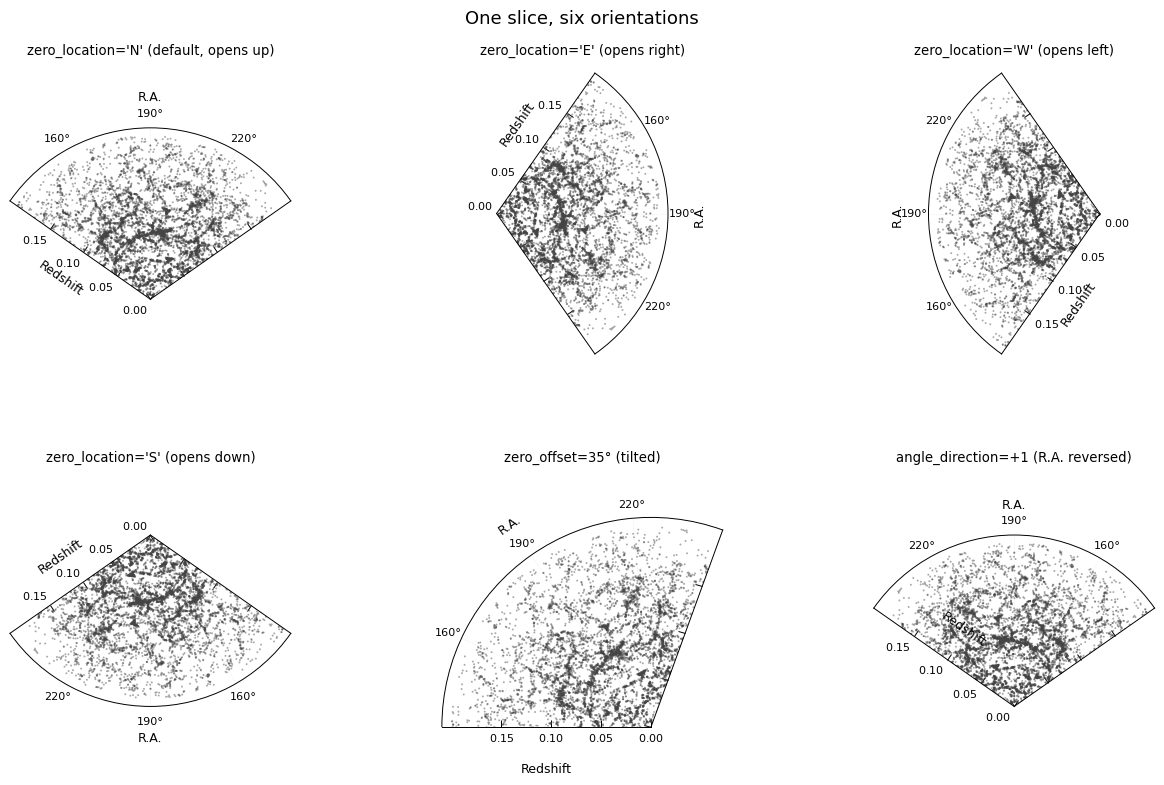

In [7]:
# fig-slug: orientation
orient = [
    dict(zero_location="N", label="zero_location='N' (default, opens up)"),
    dict(zero_location="E", label="zero_location='E' (opens right)"),
    dict(zero_location="W", label="zero_location='W' (opens left)"),
    dict(zero_location="S", label="zero_location='S' (opens down)"),
    dict(zero_location="N", zero_offset=35, label="zero_offset=35° (tilted)"),
    dict(zero_location="N", angle_direction=1,
         label="angle_direction=+1 (R.A. reversed)"),
]
fig = plt.figure(figsize=(13, 8))
for i, o in enumerate(orient):
    kw = {k: v for k, v in o.items() if k != "label"}
    ax = sph.make_cone_frame(
        231 + i, angle_center=190, angle_half_width=55,
        r_min=0.0, r_max=0.16, angle_tick_spacing=30, r_tick_spacing=0.05,
        angle_label="R.A.", label_fontsize=9, tick_fontsize=8, fig=fig, **kw,
    )
    sph.cone_scatter(ax, sdss["ra"], sdss["z"], s=2, c=GALAXY, alpha=0.45,
                     edgecolor="none")
    ax.set_title(o["label"], fontsize=9.5, pad=14)
fig.suptitle("One slice, six orientations", fontsize=13, y=0.98)
fig.subplots_adjust(left=0.04, right=0.96, top=0.90, bottom=0.04,
                    hspace=0.45, wspace=0.30)

`zero_location='E'`/`'W'` lay the cone on its side (one straight edge horizontal);
`zero_offset` reaches every angle in between; `angle_direction` handles conventions
that run the other way. These compose freely — a `'W'` wedge with a `zero_offset`
and `angle_direction=+1` is perfectly valid — which is what lets the bowtie point
its two halves in opposite directions.

## 4. The bowtie

Many surveys observe **two** patches of sky on opposite sides of the celestial
sphere — classically the North and South Galactic Pole caps, kept clear of the
Milky Way. `make_bowtie_frame` draws both as wedges sharing a single apex (the
observer), the layout the CfA "Stick Man" made famous. It returns the two halves,
each a complete cone frame that every `cone_*` helper works on independently.

The two 2dFGRS caps sit at different R.A.s, so we give each half its own
`angle_center` and `angle_half_width` (and label) through `top_kwargs` /
`bot_kwargs`, while they share the radial scale:

Text(0.5, 0.95, 'make_bowtie_frame — the two 2dFGRS caps')

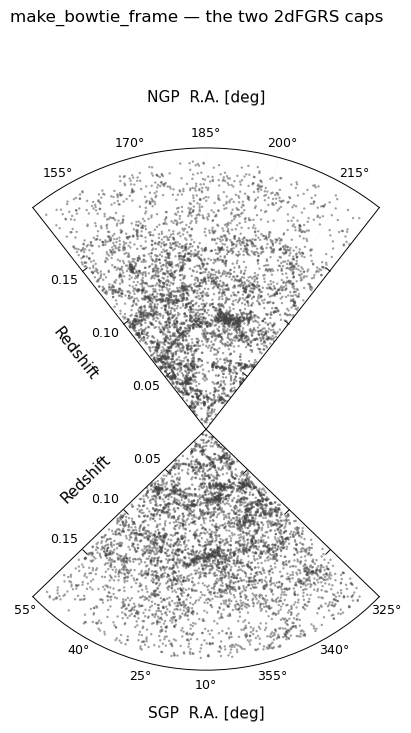

In [8]:
# fig-slug: bowtie
# NGP strip: R.A. ~148–223° (center 185, half-width 38); SGP strip: ~325–55°
# (center 10, half-width 46) — each half sized to fit its cap snugly.
fig = plt.figure(figsize=(7.5, 9))
top, bot = sph.make_bowtie_frame(
    angle_center=185, angle_half_width=45, r_min=0.0, r_max=0.15,
    angle_tick_spacing=15, r_tick_spacing=0.05,
    top_kwargs=dict(angle_center=185, angle_half_width=38,
                    angle_label="NGP  R.A. [deg]", gridcolor=to_rgb(PAL["grid"])),
    bot_kwargs=dict(angle_center=10, angle_half_width=46,
                    angle_label="SGP  R.A. [deg]", gridcolor=to_rgb(PAL["grid"])),
    fig=fig,
)
sph.cone_scatter(top, tdf["ra"][NGP], tdf["z"][NGP], s=3, c=GALAXY, alpha=0.5,
                 edgecolor="none")
sph.cone_scatter(bot, tdf["ra"][SGP], tdf["z"][SGP], s=3, c=GALAXY, alpha=0.5,
                 edgecolor="none")
fig.suptitle("make_bowtie_frame — the two 2dFGRS caps", y=0.95, fontsize=12)

North cap up, South cap down, redshift growing outward from the shared apex — the
canonical two-sided survey diagram, built from a real catalog in a single call.

Two knobs steer the layout:

- **`orientation`** — `'vertical'` (top/bottom, above) or `'horizontal'`
  (left/right, apex centered vertically).
- **`top_kwargs` / `bot_kwargs`** — anything `make_cone_frame` accepts, per half:
  here we set each cap's center, half-width, and label — the two caps span
  different R.A. ranges — but you could equally give the halves different grid
  colors or tick spacings.

The horizontal layout, with the caps distinguished by color instead:

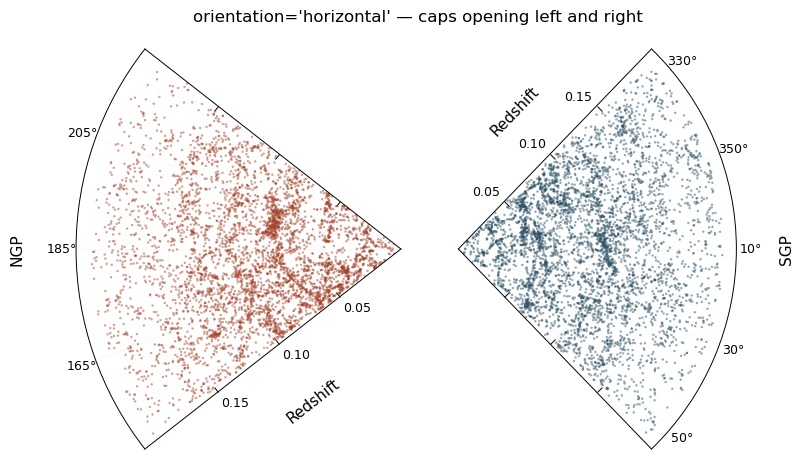

In [9]:
# fig-slug: bowtie-horizontal
fig = plt.figure(figsize=(11, 5))
left, right = sph.make_bowtie_frame(
    angle_center=185, angle_half_width=42, r_min=0.0, r_max=0.15,
    angle_tick_spacing=20, r_tick_spacing=0.05, orientation="horizontal",
    left_kwargs=dict(angle_center=185, angle_half_width=38, angle_label="NGP"),
    right_kwargs=dict(angle_center=10, angle_half_width=46, angle_label="SGP"),
    fig=fig,
)
sph.cone_scatter(left, tdf["ra"][NGP], tdf["z"][NGP], s=3, c=PAL["accent"],
                 alpha=0.5, edgecolor="none")
sph.cone_scatter(right, tdf["ra"][SGP], tdf["z"][SGP], s=3, c=PAL["accent2"],
                 alpha=0.5, edgecolor="none")
fig.suptitle("orientation='horizontal' — caps opening left and right",
             y=0.96, fontsize=12)
fig.subplots_adjust(left=0.05, right=0.95, top=0.88, bottom=0.08)

## 5. The radial axis

The radius can encode useful physical information on a cone axis. Redshift is fine
for navigating a survey, but physical distance is another important quantity, and
skyplothelper makes it easy to put on the radius. Two tools bridge the gap.

First, put a **real distance on the radius** directly. Declare the radial variable
as a comoving distance, and `cone_scatter_z` converts your redshifts to it for you:
hand it the same `(ra, z)`, and each galaxy lands at its comoving-distance radius.
`redshift_to_r` is the conversion underneath (it accepts any `cosmology=`, and
besides `'comoving_distance'` it also converts to `'lookback_time'`, for a wedge
whose radius reads in Gyr):

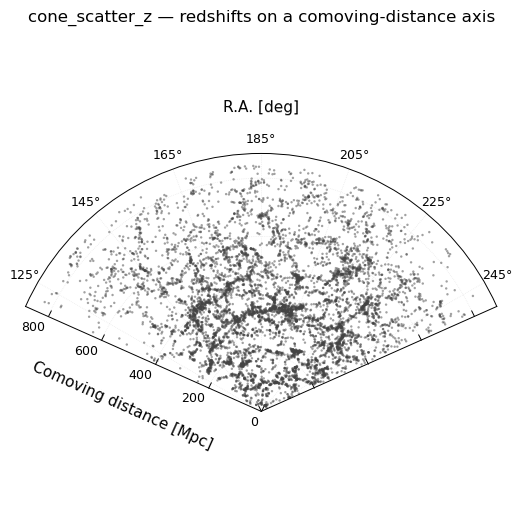

In [10]:
# fig-slug: distance-axis
fig = plt.figure(figsize=(10, 6.2))
ax = sph.make_cone_frame(111, angle_center=185, angle_half_width=66,
                         r_min=0.0, r_max=850, r_variable="comoving_distance",
                         r_unit="Mpc", cosmology=Planck18, angle_tick_spacing=20,
                         r_tick_spacing=200, angle_label="R.A. [deg]", fig=fig)
sph.cone_scatter_z(ax, sdss["ra"], sdss["z"], cosmology=Planck18,
                   s=3, c=GALAXY, alpha=0.5, edgecolor="none")
ax.set_title("cone_scatter_z — redshifts on a comoving-distance axis", pad=18)
fig.subplots_adjust(left=0.06, right=0.90, top=0.86, bottom=0.10)

The wedge now reads directly in megaparsecs. But you often want *both* — redshift
to navigate, distance to interpret. `make_twinr` adds a **second radial scale** on
the opposite edge, defined by a conversion function, so the same galaxies carry two
rulers at once:

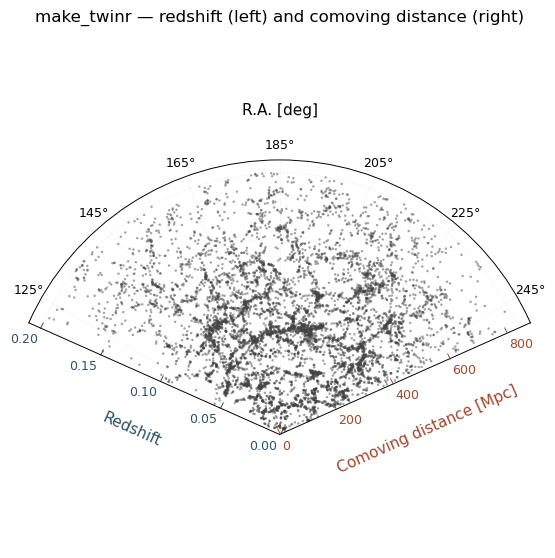

In [11]:
# fig-slug: twin-axis
fig = plt.figure(figsize=(10.5, 6.6))
ax = sph.make_cone_frame(111, angle_center=185, angle_half_width=66,
                         r_min=0.0, r_max=0.20, angle_tick_spacing=20,
                         r_tick_spacing=0.05, angle_label="R.A. [deg]",
                         radial_axis_side="left", radial_axis_color=PAL["accent2"],
                         fig=fig)
sph.cone_scatter(ax, sdss["ra"], sdss["z"], s=3, c=GALAXY, alpha=0.5,
                 edgecolor="none")

# a twin radial axis on the right, in comoving Mpc
twin = sph.make_twinr(
    ax,
    convert=lambda z: sph.redshift_to_r(z, r_variable="comoving_distance",
                                        cosmology=Planck18, r_unit="Mpc"),
    r_label="Comoving distance [Mpc]", r_tick_spacing=200,
    color=ACCENT,
)
ax.set_title("make_twinr — redshift (left) and comoving distance (right)", pad=18)
fig.subplots_adjust(left=0.10, right=0.86, top=0.86, bottom=0.10)

Redshift on the left edge, the *same* galaxies read off in megaparsecs on the
right. The `color=` on the twin (and `radial_axis_color=` on the parent) tie each
scale to its axis — a small touch that stops the two number systems from being
confused.

Two more radial controls, shown together on a deep, foreground-heavy sample. Real
surveys pile up at low redshift, so a **log radial axis** (`log_r`) spreads the
crowded foreground out; **`add_minor_rticks`** adds unlabeled minor divisions for
finer reading:

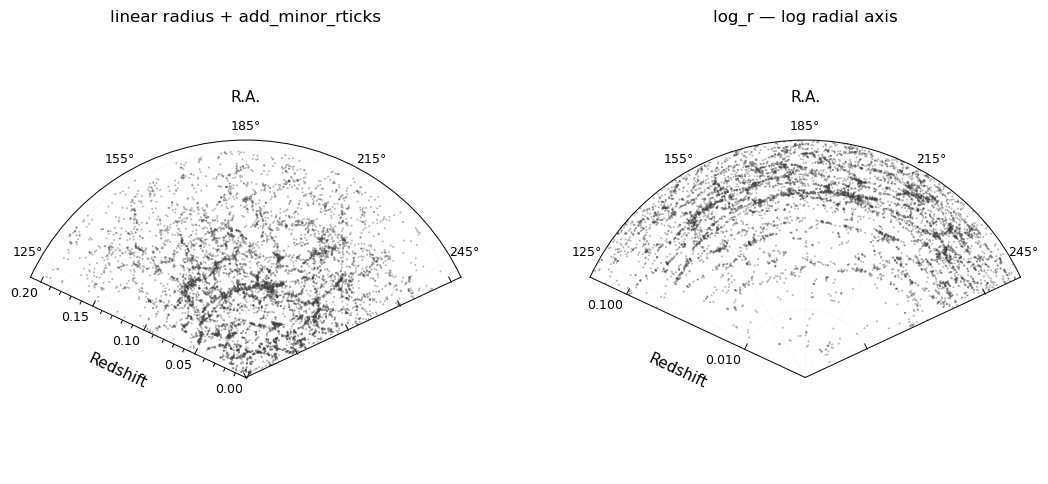

In [12]:
# fig-slug: log-radius
fig = plt.figure(figsize=(11, 5.6))

# (a) linear radius — the foreground is compressed near the apex
ax_lin = sph.make_cone_frame(121, angle_center=185, angle_half_width=65,
                             r_min=0.0, r_max=0.20, angle_tick_spacing=30,
                             r_tick_spacing=0.05, angle_label="R.A.", fig=fig)
sph.cone_scatter(ax_lin, sdss["ra"], sdss["z"], s=2, c=GALAXY, alpha=0.4,
                 edgecolor="none")
sph.add_minor_rticks(ax_lin, step=0.01)                 # minor ticks every Δz = 0.01
ax_lin.set_title("linear radius + add_minor_rticks", pad=16)

# (b) log radius — the foreground structure opens up
ax_log = sph.make_cone_frame(122, angle_center=185, angle_half_width=65,
                             r_min=0.003, r_max=0.20, angle_tick_spacing=30,
                             angle_label="R.A.", fig=fig)
sph.log_r(ax_log)                                        # switch radius to log scale
sph.cone_scatter(ax_log, sdss["ra"], sdss["z"], s=2, c=GALAXY, alpha=0.4,
                 edgecolor="none")
ax_log.set_rmin(0.003)
ax_log.set_rmax(0.20)
ax_log.set_title("log_r — log radial axis", pad=16)
fig.subplots_adjust(left=0.05, right=0.95, top=0.85, bottom=0.08, wspace=0.30)

> **Note:** The radial labels sit on the slanted wedge edge, which can leave them
> at an awkward angle. `flip_label(ax._cone_r_label_text)` turns a label 180° to
> the more readable direction, and `set_label_pad(text, pad)` / `get_label_pad`
> nudge its distance from the axis — useful when a large font or a tight layout
> crowds the edge.

## 6. Beyond cosmology

Nothing about the wedge is intrinsically cosmological. It is a natural frame for
**any** measurement of *something versus an angle* — the observer (or a source, or
an origin) sits at the apex, an angle opens the fan, and a radial quantity runs
outward. Three quick examples that have nothing to do with redshift.

**(a) A radio jet.** Knots in an AGN jet, plotted as position angle on the sky
versus projected distance from the core — the wedge shows the jet's slight bending
far more naturally than a Cartesian plot:

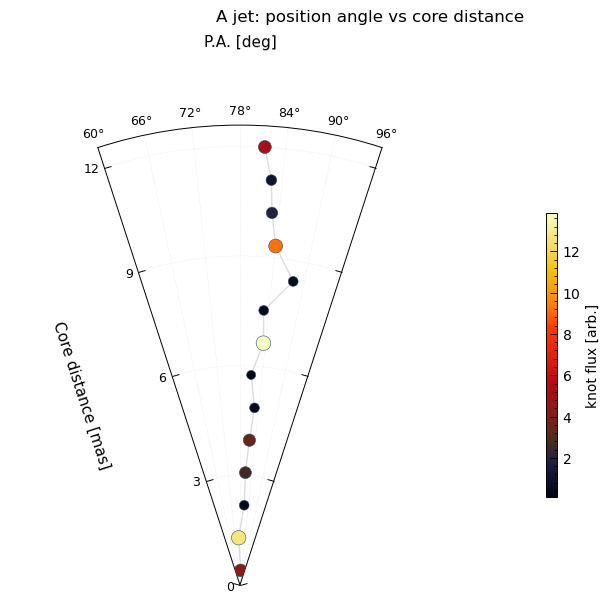

In [13]:
# fig-slug: generic-jet
rng = np.random.default_rng(3)
n = 14
core_dist = np.linspace(0.4, 12.0, n)                    # mas from the core
pa = 78 + 6 * np.sin(core_dist / 5) + rng.normal(0, 1.2, n)   # gently bending jet
flux = 10 ** rng.uniform(-1, 1.2, n)

fig = plt.figure(figsize=(7.5, 6.4))
ax = sph.make_cone_frame(111, angle_center=78, angle_half_width=18,
                         r_min=0.0, r_max=12.5,
                         angle_tick_spacing=6, r_tick_spacing=3,
                         angle_label="P.A. [deg]", r_label="Core distance [mas]",
                         zero_location="N", fig=fig)
sph.cone_plot(ax, pa, core_dist, color=PAL["grid"], lw=1.0, zorder=1)
sc = sph.cone_scatter(ax, pa, core_dist, s=40 + 60 * np.log10(flux + 1),
                      c=flux, cmap="sph.sunset", edgecolor=PAL["label"],
                      linewidth=0.4, zorder=3)
sph.add_colorbar(sc, ax=ax, label="knot flux [arb.]", shrink=0.6, pad=0.12,
                 mode="simple")
fig.suptitle("A jet: position angle vs core distance", y=0.99, fontsize=12)
fig.subplots_adjust(left=0.02, right=0.86, top=0.82, bottom=0.08)

**(b) An azimuthal profile.** Any quantity measured *around* a center — an azimuth
on one axis, a radius on the other. Here, mock surface-brightness samples around a
galaxy, with two spiral-arm overdensities showing up as bright ridges:

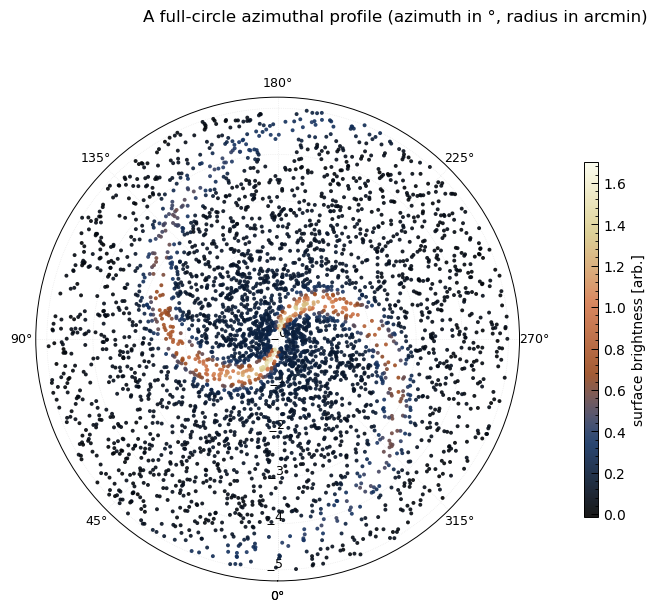

In [14]:
# fig-slug: generic-azimuthal
rng = np.random.default_rng(11)
az = rng.uniform(0, 360, 4000)
rad = rng.uniform(0.2, 5.0, 4000)
# brightness falls off with radius and rises sharply along two arms 180° apart
arm = np.exp(-((np.sin(np.radians(az - rad * 40)))**2) / 0.06)
bright = np.exp(-rad / 2.8) * (0.25 + 1.6 * arm) + rng.normal(0, 0.02, az.size)

fig = plt.figure(figsize=(7.5, 6.8))
# On a full circle both axis labels get placed awkwardly inside the disk, so we
# suppress them (angle_label='' / r_label='') and let the tick numbers speak: degrees
# of azimuth around the rim, radius in arcmin along the spoke.
ax = sph.make_cone_frame(111, angle_center=180, angle_half_width=180,
                         r_min=0.0, r_max=5.0,
                         angle_tick_spacing=45, r_tick_spacing=1,
                         angle_label="", r_label="",
                         fig=fig)
sc = sph.cone_scatter(ax, az, rad, s=8, c=bright, cmap="sph.deepsky",
                      alpha=0.9, edgecolor="none")
sph.add_colorbar(sc, ax=ax, label="surface brightness [arb.]", shrink=0.6,
                 pad=0.10, mode="simple")
fig.suptitle("A full-circle azimuthal profile (azimuth in °, radius in arcmin)",
             y=0.97, fontsize=12)
fig.subplots_adjust(left=0.02, right=0.88, top=0.92, bottom=0.05)

A half-width of 180° closes the wedge into a full disk — the cone frame degrades
gracefully to an ordinary polar plot when you want the whole circle.

**(c) Time as the radius.** The radial axis need not be a distance at all. Here the
expansion of a supernova remnant: azimuth around the shell on the angular axis,
**epoch** on the radius, each point a knot detected at that position and time,
colored by its measured expansion speed (a **diverging** bundled map,
`sph.diff_blueorange`, since speeds spread around a typical value — slow knots
blue, fast knots orange):

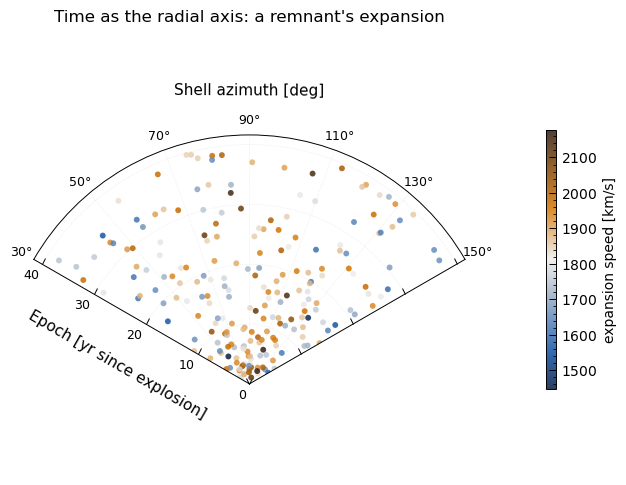

In [15]:
# fig-slug: generic-time
rng = np.random.default_rng(1)
n = 220
shell_az = rng.uniform(30, 150, n)
epoch = rng.uniform(1.0, 40.0, n)                        # years since explosion
speed = 1500 + 400 * np.sin(np.radians(shell_az)) + rng.normal(0, 120, n)

fig = plt.figure(figsize=(8, 5.6))
ax = sph.make_cone_frame(111, angle_center=90, angle_half_width=60,
                         r_min=0.0, r_max=40,
                         angle_tick_spacing=20, r_tick_spacing=10,
                         angle_label="Shell azimuth [deg]",
                         r_label="Epoch [yr since explosion]", fig=fig)
sc = sph.cone_scatter(ax, shell_az, epoch, s=18, c=speed,
                      cmap="sph.diff_blueorange", alpha=0.85, edgecolor="none")
sph.add_colorbar(sc, ax=ax, label="expansion speed [km/s]", shrink=0.6, pad=0.12,
                 mode="simple")
ax.set_title("Time as the radial axis: a remnant's expansion", pad=16)
fig.subplots_adjust(left=0.02, right=0.86, top=0.87, bottom=0.10)

## 7. Putting it together

A capstone that stacks the toolkit into one publication-ready figure of the SDSS
slice: hexbin **density** to show the web without over-plotting, a **twin
comoving-distance axis** so the depth is readable in megaparsecs, **minor radial ticks**,
and the Great Wall called out. Swap in your own `(ra, z)` and cosmology and this is
your survey.

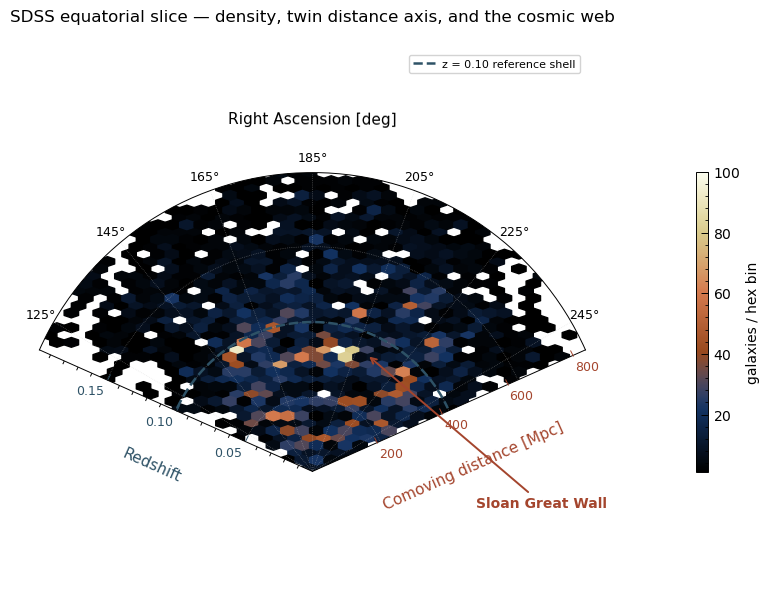

In [16]:
# fig-slug: capstone
fig = plt.figure(figsize=(11.5, 7))
ax = sph.make_cone_frame(
    111, angle_center=185, angle_half_width=66, r_min=0.0, r_max=0.20,
    angle_tick_spacing=20, r_tick_spacing=0.05, angle_label="Right Ascension [deg]",
    radial_axis_side="left", radial_axis_color=PAL["accent2"], fig=fig,
)
hb = sph.cone_hexbin(ax, sdss["ra"], sdss["z"], gridsize=36, cmap="sph.deepsky",
                     mincnt=1)
sph.add_minor_rticks(ax, step=0.01)
cb = sph.add_colorbar(hb, ax=ax, label="galaxies / hex bin",
                      shrink=0.55, pad=0.13, mode="simple")

twin = sph.make_twinr(
    ax,
    convert=lambda z: sph.redshift_to_r(z, r_variable="comoving_distance",
                                        cosmology=Planck18, r_unit="Mpc"),
    r_label="Comoving distance [Mpc]", r_tick_spacing=200, color=ACCENT,
)

# overlay a reference shell — cone_plot draws a line on the density just as readily
# as on a scatter, the wedge equivalent of an axhline for marking a redshift of note
shell_ra = np.linspace(120, 250, 240)
sph.cone_plot(ax, shell_ra, np.full_like(shell_ra, 0.10), color=PAL["accent2"],
              lw=1.8, ls="--", label="z = 0.10 reference shell")
ax.legend(loc="upper right", fontsize=8, framealpha=0.85)

# call out the Great Wall (RA ~ 200, z ~ 0.08)
ax.annotate("Sloan Great Wall", xy=(0.60, 0.44), xytext=(0.80, 0.16),
            xycoords="axes fraction", textcoords="axes fraction",
            fontsize=10, fontweight="bold", color=ACCENT, ha="left",
            arrowprops=dict(arrowstyle="->", color=ACCENT, lw=1.4))
ax.set_title("SDSS equatorial slice — density, twin distance axis, "
             "and the cosmic web", pad=20)
fig.subplots_adjust(left=0.10, right=0.84, top=0.88, bottom=0.10)

That is the whole arc in one frame: a real survey (§1), rendered as density (§2),
with a second physical scale on the radius (§5), and a `cone_plot` reference shell
overlaid to mark a redshift of interest — the "slice of the universe" you opened
with, now fully labeled and ready for a paper.

## 8. Where to go next

- **[Cone frames guide](../guide/cone.md)** — the reference companion to this tour:
  the full argument list, the twin-axis internals, and the pitfalls (cone frames
  aren't WCSAxes, angles are degrees, hexbin-vs-pcolormesh inputs).
- **[A Tour of Projections](projections.ipynb)** — the WCS sky frames that cone
  frames deliberately are *not*; where to plot the same catalog *on the sky*.
- **[Catalogs](catalogs.ipynb)** — getting the `(ra, dec, z)` tables in the
  first place: name resolution, SIMBAD/VizieR/SkyView queries, and plotting
  catalogs on sky frames.
- The distance/time conversions come from `astropy.cosmology`; pass any
  `cosmology=` object to `redshift_to_r` and `make_twinr` to match your survey's
  assumed cosmology instead of the `Planck18` default.